In [1]:
import pandas as pd

In [2]:
a = pd.read_csv('crmls_last_6_months.csv')
a.shape

/var/folders/5h/xj31sbws0v1fsydb5s7s1wlh0000gn/T/ipykernel_95710/3940642160.py:1: DtypeWarning: Columns (79,80) have mixed types. Specify dtype option on import or set low_memory=False.
  a = pd.read_csv('crmls_last_6_months.csv')


(61886, 81)

In [3]:
df = pd.read_csv('fixed_cleaned_crmls_dataset')
df = df.drop(columns = ['Unnamed: 0'])
df = df.astype({col: int for col in df.select_dtypes(bool).columns})
# display(df)

In [4]:
df.dtypes

ViewYN                     int64
PoolPrivateYN              int64
ClosePrice               float64
Latitude                 float64
Longitude                float64
LivingArea               float64
CountyOrParish            object
AttachedGarageYN           int64
ParkingTotal             float64
BathroomsTotalInteger    float64
City                      object
BedroomsTotal            float64
FireplaceYN                int64
LotSizeArea              float64
NewConstructionYN          int64
HighSchoolDistrict        object
PostalCode                object
BuildingAge              float64
StoriesFinal              object
dtype: object

In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = df.drop(columns = ['ClosePrice'])
y = df.ClosePrice

display(X)
display(y)

,ViewYN,PoolPrivateYN,Latitude,Longitude,LivingArea,CountyOrParish,AttachedGarageYN,ParkingTotal,BathroomsTotalInteger,City,BedroomsTotal,FireplaceYN,LotSizeArea,NewConstructionYN,HighSchoolDistrict,PostalCode,BuildingAge,StoriesFinal
0,1,0,33.725080,-117.222302,2824.0,24,1,2.0,3.0,345,5.0,0,7000.0,1,174,477,1.0,1
1,1,0,34.203479,-118.643567,2500.0,12,1,2.0,3.0,321,5.0,1,8336.0,0,38,180,54.0,1
2,0,0,34.460368,-118.490755,2363.0,12,1,2.0,3.0,553,5.0,1,11705.0,0,341,210,30.0,1
3,0,0,34.043218,-118.519477,3338.0,12,0,2.0,5.0,425,4.0,1,6502.0,0,350,77,21.0,1
4,0,0,37.669495,-121.763793,2485.0,0,1,2.0,3.0,309,4.0,1,5093.0,0,153,888,14.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35772,0,0,33.700193,-117.371513,1435.0,24,1,2.0,2.0,289,3.0,0,6680.0,1,144,456,1.0,0
35773,1,0,34.378787,-117.330930,2226.0,27,1,2.0,3.0,234,4.0,1,18000.0,0,121,416,35.0,1
35774,1,0,34.854045,-119.148141,1753.0,9,1,2.0,3.0,446,3.0,1,10104.0,0,91,601,19.0,1
35775,1,0,33.891018,-118.087100,1186.0,12,0,4.0,1.0,399,2.0,1,6211.0,0,201,115,76.0,0


0         681877.0
1         900000.0
2         862000.0
3        5149000.0
4        1710000.0
           ...    
35772     566990.0
35773     495000.0
35774     435000.0
35775     740000.0
35776     575000.0
Name: ClosePrice, Length: 35777, dtype: float64

In [13]:
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

my_model = XGBRegressor(n_estimators=500, learning_rate=0.1, random_state=42)

my_model.fit(X_train, y_train_log,
             eval_set=[(X_test, y_test_log)],
            verbose=False)

y_pred_log = my_model.predict(X_test)
y_pred = np.expm1(y_pred_log)


print("MAPE:", mean_absolute_percentage_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAPE: 0.11347770628621372
R2: 0.8232973474596965


<Figure size 1000x800 with 0 Axes>

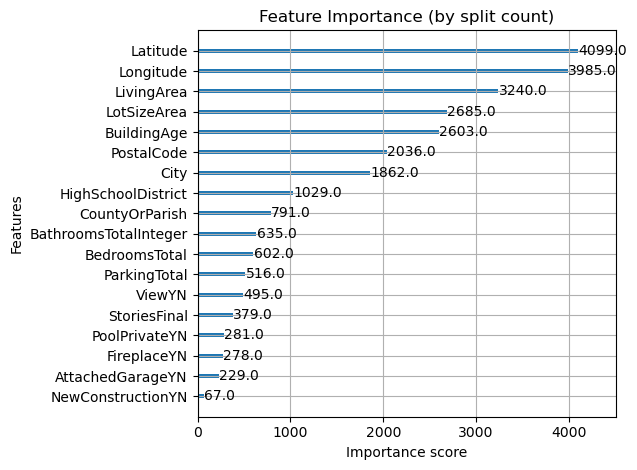

In [14]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_importance(my_model, importance_type='weight')
plt.title("Feature Importance (by split count)")
plt.tight_layout()
plt.show()

In [24]:
!pip install shap

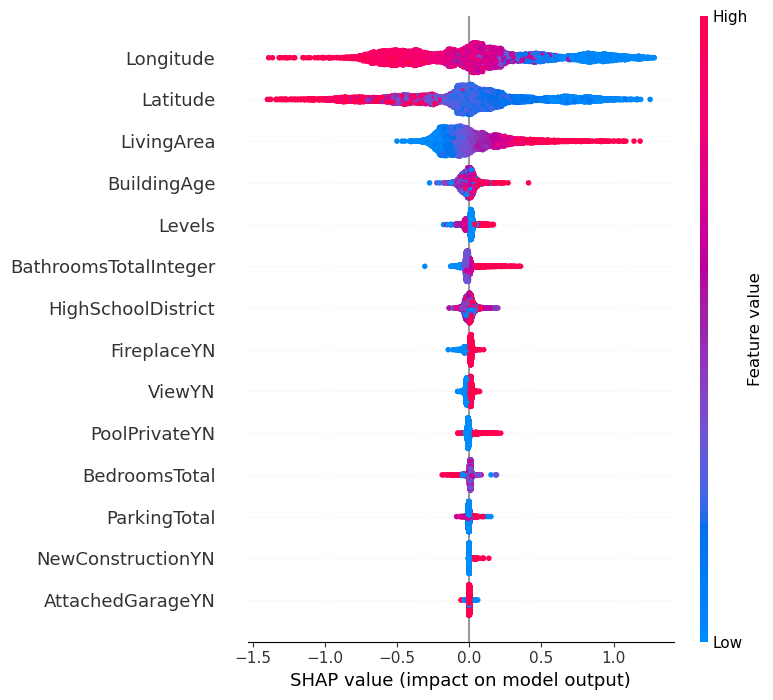

In [25]:
import shap

explainer = shap.Explainer(my_model)
shap_values = explainer(X_test)

# summary plot: shows how each feature (y‐axis) impacts the prediction (color=feature value)
shap.summary_plot(shap_values, X_test)


In [26]:
jun2025 = pd.read_csv('test_data')
jun2025 = jun2025.drop(columns=['Unnamed: 0'])
jun2025 = jun2025.astype({col: int for col in jun2025.select_dtypes(bool).columns})
for col in jun2025.select_dtypes(include='object').columns:
    jun2025[col] = LabelEncoder().fit_transform(jun2025[col].astype(str))

# display(jun2025)

X_jun = jun2025.drop(columns = ['ClosePrice','CountyOrParish','LotSizeArea','PostalCode', 'City'])
y_jun = jun2025.ClosePrice
y_jun_log = np.log1p(y_jun)

y_jun_pred_log = my_model.predict(X_jun)
y_jun__pred = np.expm1(y_jun_pred_log)


print("MAPE:", mean_absolute_percentage_error(y_jun, y_jun__pred))
print("R2:", r2_score(y_jun, y_jun__pred))

MAPE: 0.12236666650074962
R2: 0.7791851648049919


In [30]:
jun2025['ClosePrice'].describe()

count    6.738000e+03
mean     1.143883e+06
std      9.612034e+05
min      7.000000e+04
25%      6.250000e+05
50%      8.745000e+05
75%      1.350000e+06
max      1.790000e+07
Name: ClosePrice, dtype: float64

In [31]:
df['ClosePrice'].describe()

count    3.577700e+04
mean     1.162583e+06
std      5.271392e+06
min      1.150000e+00
25%      6.229900e+05
50%      8.700000e+05
75%      1.325000e+06
max      9.700000e+08
Name: ClosePrice, dtype: float64